<a href="https://colab.research.google.com/github/Atharva6907/ML-Practice-Projects/blob/main/FashionMNIST_NN_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# PROJECT 1: BUILDING A NEURAL NETWORK ON THE FASHIONMNIST DATASET

In [ ]:
# First let's start by importing all our modules

In [ ]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt

In [ ]:
# Setting runtime to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Next, from torchvision --> datasets we will import the FashionMNIST dataset and transforming it as:
# v2.ToImage() which takes the raw PIL Image and converts it into a PyTorch Tensor.
# v2.ToDtype(torch.float32, scale=True) which
# 1) Type conversion: converts all the colour bits (0 to 255) to float32 since a neural network needs decimal numbers to calculate gradients during backpropagation.
# 2) Scaling: Divides every number by 255.0 to scale it between 0 and 1

# We could have also used v1.ToTensor() which does both in a single step but this is an older and slower way.

In [ ]:
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.93MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.4MB/s]


In [ ]:
# Load data using the Data Loader

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)

print(f"Training samples : {len(train_data)}")
print(f"Test samples     : {len(test_data)}")
print(f"Input shape for one batch: {next(iter(train_loader))[0].shape}")

Training samples : 60000
Test samples     : 10000
Input shape for one batch: torch.Size([64, 1, 28, 28])


In [ ]:
# Visualize the loaded data once before going ahead

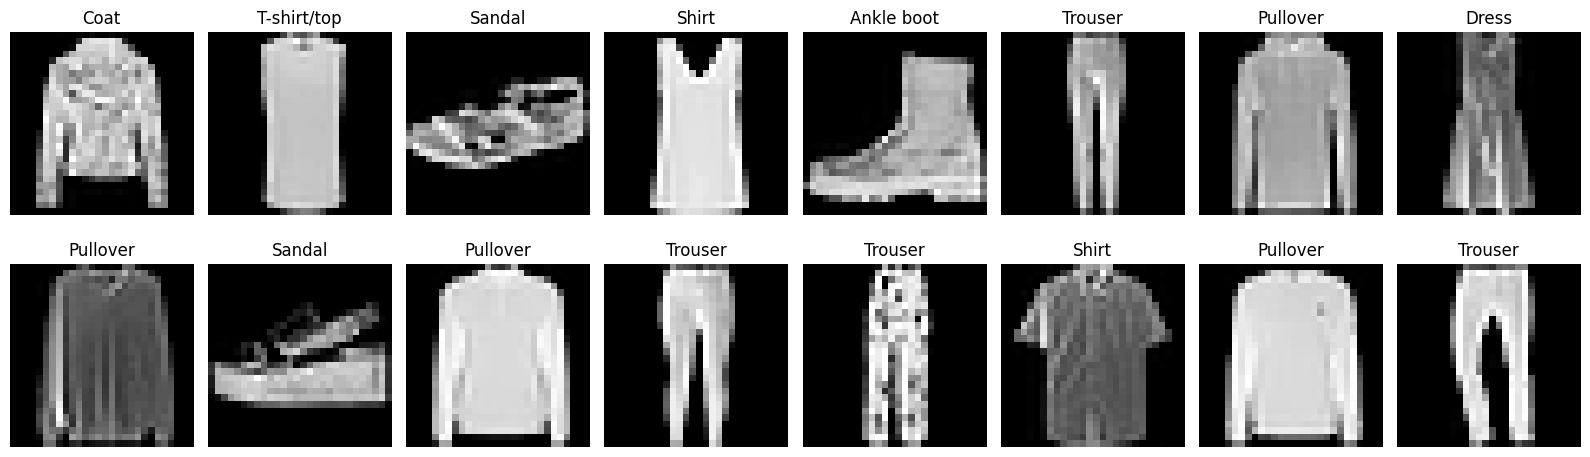

In [ ]:
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(class_names[labels[i]])
    ax.axis('off')
plt.tight_layout()
plt.show()

# Source: PyTorch official documentation

In [ ]:
# Now that we have loaded the data, let's start with building our Multi Layer Perceptron (MLP Model)
# For this we will be using 2 hideen layers as follows: 784(input) --> 512(Hidden_Layer_1) --> 128(Hidden_Layer_2) --> 10(Output_Layer)

# Some changes: I added Dropouts to my network to reduce the overfitting I was getting without them

In [ ]:
import torch.nn as nn
import torch.optim as optim

class FashionMLP(nn.Module):
    def __init__(self):
        super(FashionMLP, self).__init__()

        self.network = nn.Sequential(
            nn.Flatten(),           #Input

            nn.Linear(784, 512),    # Hidden Layer 1
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 128),    # Hidden Layer 2
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 10)      # Output
        )

    def forward(self, x):
        return self.network(x)


model = FashionMLP().to(device)
print(model)

FashionMLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [ ]:
# Define Loss and Optimizer for the modl

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
# Now let's code up the training loop
# We will be following the loop given in the Readme for this: Train mode ➡️ Forward Pass ➡️ Calculate Loss ➡️ Zero Gradients ➡️ Backward Pass ➡️ Optimizer Step.
# One call to this function = one full pass through the entire training set forward backward combined.

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct = 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)  # moves data to GPU

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Zero Gradients
        optimizer.zero_grad()

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()

    # Calculating how well our model fits on the trainingt data

    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct   / len(loader.dataset) * 100
    return avg_loss, accuracy

In [ ]:
# Let's code up the evaluation loop now which will check how our model is performing in general on the test data

In [ ]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()

    # Calculating how well our model fits on the testing data

    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct   / len(loader.dataset) * 100
    return avg_loss, accuracy

In [ ]:
# Let's now do the actual fitting to our model. We will write a loop which runs some fixed number of epochs and during those,
# 1) trains the model, 2) Checks the model accuracy on test data, 3) Continues to next iteration while also storing these datas in a list for plotting it afterwards

In [ ]:
EPOCHS = 10
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc   = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc   = evaluate(model, test_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.2f}% | "
          f"Test  Loss: {test_loss:.4f}  Acc: {test_acc:.2f}%")

Epoch 01/10 | Train Loss: 0.5683  Acc: 79.61% | Test  Loss: 0.4234  Acc: 84.73%
Epoch 02/10 | Train Loss: 0.4129  Acc: 84.97% | Test  Loss: 0.3904  Acc: 86.30%
Epoch 03/10 | Train Loss: 0.3799  Acc: 86.11% | Test  Loss: 0.3672  Acc: 86.56%
Epoch 04/10 | Train Loss: 0.3582  Acc: 86.98% | Test  Loss: 0.3596  Acc: 86.99%
Epoch 05/10 | Train Loss: 0.3441  Acc: 87.34% | Test  Loss: 0.3709  Acc: 86.82%
Epoch 06/10 | Train Loss: 0.3300  Acc: 87.79% | Test  Loss: 0.3393  Acc: 87.46%
Epoch 07/10 | Train Loss: 0.3171  Acc: 88.25% | Test  Loss: 0.3497  Acc: 87.41%
Epoch 08/10 | Train Loss: 0.3130  Acc: 88.48% | Test  Loss: 0.3685  Acc: 86.80%
Epoch 09/10 | Train Loss: 0.3024  Acc: 88.68% | Test  Loss: 0.3387  Acc: 87.75%
Epoch 10/10 | Train Loss: 0.2950  Acc: 89.13% | Test  Loss: 0.3339  Acc: 87.86%


In [ ]:
# Now let's plot the training curve for our model

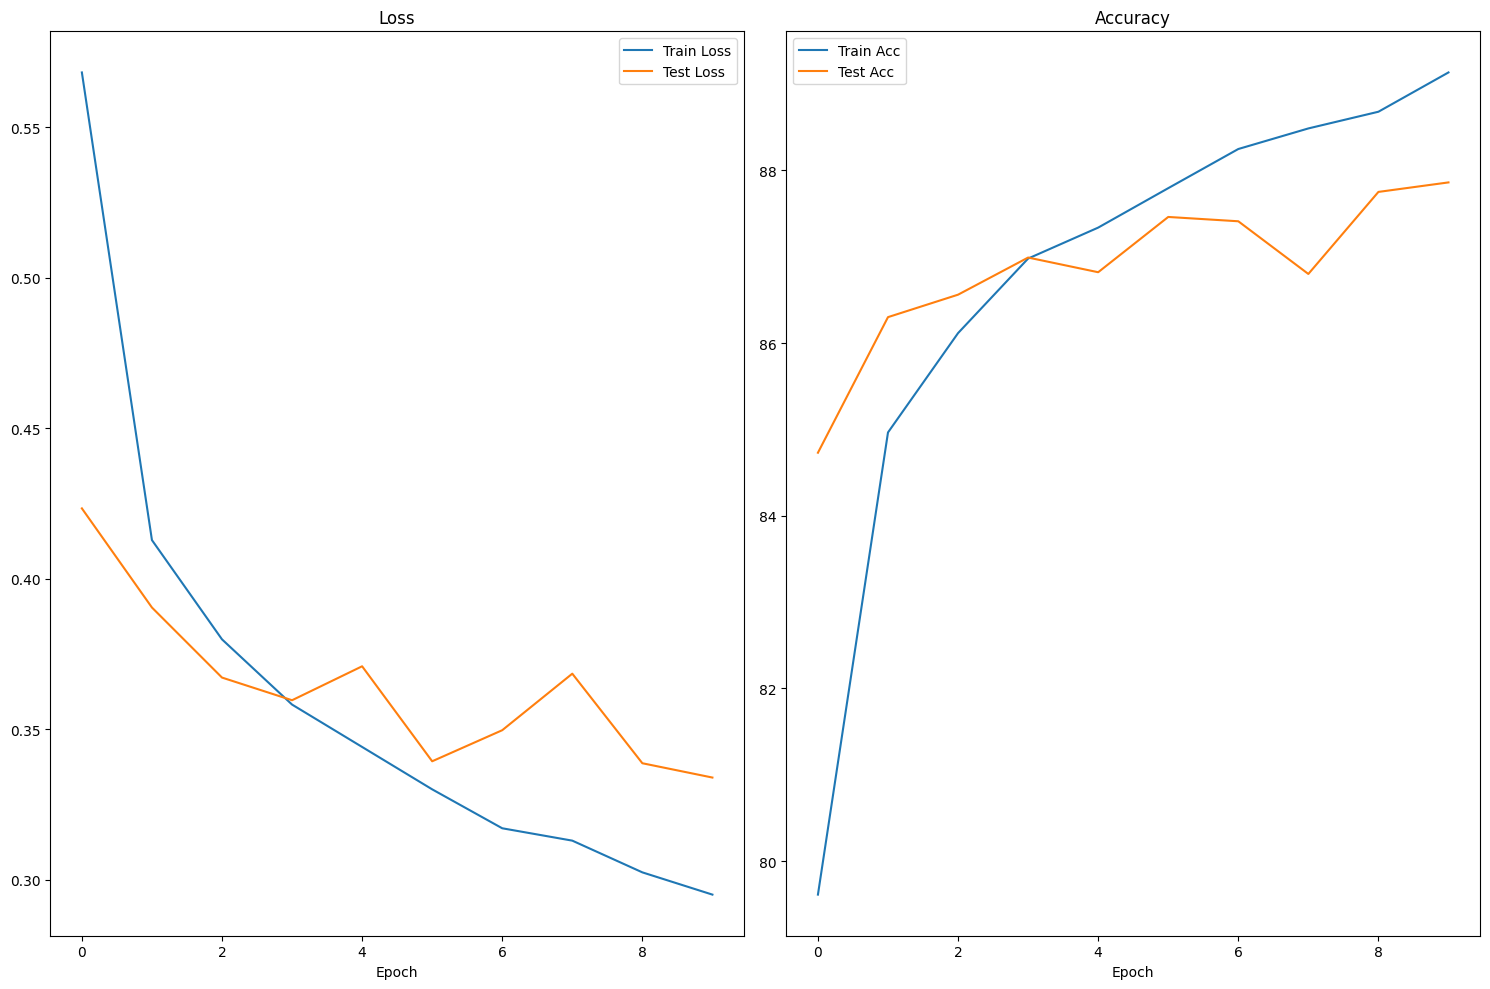

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 10))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['test_loss'],  label='Test Loss')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history['train_acc'], label='Train Acc')
ax2.plot(history['test_acc'],  label='Test Acc')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Given below is the final predictions made by the model on the first 10 test sample

In [ ]:
all_preds = []
model.eval()

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)

print(f"Total predictions: {len(all_preds)}")
print(f"Sample predictions: {all_preds[:10]}")

Total predictions: 10000
Sample predictions: [np.int64(9), np.int64(2), np.int64(1), np.int64(1), np.int64(6), np.int64(1), np.int64(4), np.int64(6), np.int64(5), np.int64(7)]


**WE CAN SEE THE PREDICTIONS MADE BY OUR MODEL ON THE FIRST 10 IMAGES OF THE DATASET AND USING ONLINE AVAILABLE DATA I HAVE CROSS CHECKED THAT ALL 10 OF THESE PREDICTIONS MATCH THE ACTUAL LABEL**

In [ ]:
# Now let's try running our predictions on the data given to us (of 100 images)

In [ ]:
from google.colab import files
import zipfile

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

with zipfile.ZipFile('test_set.zip', 'r') as z:
    z.extractall('.')
    print("Extracted all")
# Source: https://colab.research.google.

Saving test_set.zip to test_set.zip
User uploaded file "test_set.zip" with length 103725 bytes
Extracted all


In [ ]:
from PIL import Image
import os

print(os.listdir('/content/images'))
test_dir = '/content/images'

['006.png', '047.png', '092.png', '026.png', '068.png', '017.png', '074.png', '041.png', '076.png', '096.png', '010.png', '043.png', '058.png', '009.png', '015.png', '095.png', '019.png', '005.png', '022.png', '069.png', '042.png', '070.png', '075.png', '046.png', '031.png', '081.png', '077.png', '073.png', '063.png', '004.png', '018.png', '038.png', '067.png', '066.png', '033.png', '050.png', '089.png', '097.png', '054.png', '002.png', '085.png', '098.png', '003.png', '056.png', '099.png', '013.png', '040.png', '051.png', '057.png', '014.png', '079.png', '008.png', '080.png', '030.png', '023.png', '064.png', '086.png', '035.png', '060.png', '037.png', '093.png', '027.png', '088.png', '034.png', '062.png', '083.png', '020.png', '024.png', '000.png', '028.png', '036.png', '016.png', '090.png', '029.png', '052.png', '059.png', '065.png', '044.png', '094.png', '025.png', '001.png', '071.png', '032.png', '011.png', '055.png', '049.png', '078.png', '091.png', '039.png', '021.png', '082.png'

In [ ]:
class ImgDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.image_files = sorted([
            f for f in os.listdir(img_dir) if f.endswith('.png')
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.image_files[idx])
        image = Image.open(img_path)
        if self.transform:
            image = self.transform(image)
        image_id = self.image_files[idx].replace('.png', '')
        return image, image_id

In [ ]:
from torchvision import transforms
my_transform = transforms.ToTensor()

submission_dataset = ImgDataset(test_dir, transform=my_transform)
submission_loader = DataLoader(submission_dataset, batch_size=64, shuffle=False)

print(f"submission_dataset.head(): {[submission_dataset.image_files[i] for i in range(5)]}")

submission_dataset.head(): ['000.png', '001.png', '002.png', '003.png', '004.png']


In [ ]:
import pandas as pd

submission_ids   = []
submission_preds = []

model.eval()
with torch.no_grad():
    for images, image_ids in submission_loader:
        images  = images.to(device)
        outputs = model(images)
        preds   = outputs.argmax(dim=1).cpu().numpy()

        submission_ids.extend(image_ids)
        submission_preds.extend(preds)

submission_df = pd.DataFrame({
    'image_id': submission_ids,
    'label':    submission_preds
})

submission_df.to_csv('nn_submission.csv', index=False)
print(submission_df)
print("\nSaved as nn_submission.csv")

   image_id  label
0       000      5
1       001      3
2       002      7
3       003      2
4       004      3
..      ...    ...
95      095      6
96      096      9
97      097      7
98      098      9
99      099      7

[100 rows x 2 columns]

Saved as nn_submission.csv


In [ ]:
# NOTE: ALL THE CODES IN THIS PROJECT HAVE BEEN TAKEN EITHER FROM THE OFFICIAL PYTORCH DOCUMENTATIOn OR PYTORCH TUTORIAL BY FREECODECAMP.ORG

# LET'S NOW TRY SOLVING THE SAME PROBLEM USING CNN
# PROJECT 2: BUILDING A CONVOLUTIONAL NEURAL NETWORK ON THE FASHIONMNIST DATASET

In [ ]:
# We already have the data loaded

In [ ]:
# Let's now move on to building the model.
# For it the general architecture would be of the following type:

# Input [64, 1, 28, 28]
#    ↓
# Conv Block 1: Conv2D → ReLU → MaxPool2D
#    ↓ [64, 32, 14, 14]
# Conv Block 2: Conv2D → ReLU → MaxPool2D
#    ↓ [64, 64, 7, 7]
# Conv Block 3: Conv2D → ReLU
#    ↓ [64, 128, 7, 7]
# Flatten
#    ↓ [64, 6272]  (128 × 7 × 7)
# Linear → ReLU → Dropout → Linear
#    ↓ [64, 10]

# The idea for building such a model which uses the ReLU activation function along with alternate Conv and Pool layers is something we always notice in models such as AlexNET/ ZFNet etc.
# Can refer to my Github for my attempt on implementing these research papers/ models
# Updates: Changed from my older AlexNet inspired network to a VGG Style Setup with Batch Normalization and 2 Conv --> 1 Max Pool instead of 1 Conv --> 1 Max Pool

In [ ]:
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25),

            # Block 2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25),

            # Block 3 — not pooling this time, just extracting some more features
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = FashionCNN().to(device)
print(model)

FashionCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout2d(p=0.25, 

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4) # Adding a L2 regulariztion penalty here to avoid over-fitting and improve accuracy
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3) # Using this since my accuracy was bouncing off after 14 epochs and not settling

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct = 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()

    # Calculating how well our model fits on the training data

    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct   / len(loader.dataset) * 100

    return avg_loss, accuracy

In [ ]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()

    # Calculating how well our model fits on the testing data

    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct   / len(loader.dataset) * 100
    return avg_loss, accuracy

    scheduler.step(accuracy)

In [ ]:
# Let's finally train our model and see how accurately it performs on the dataset

In [ ]:
EPOCHS = 10
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.2f}% | "
          f"Test  Loss: {test_loss:.4f}  Acc: {test_acc:.2f}%")

Epoch 01/10 | Train Loss: 0.4007  Acc: 85.39% | Test  Loss: 0.2764  Acc: 90.04%
Epoch 02/10 | Train Loss: 0.2783  Acc: 89.90% | Test  Loss: 0.2370  Acc: 91.47%
Epoch 03/10 | Train Loss: 0.2462  Acc: 91.05% | Test  Loss: 0.2312  Acc: 91.68%
Epoch 04/10 | Train Loss: 0.2278  Acc: 91.72% | Test  Loss: 0.2143  Acc: 91.96%
Epoch 05/10 | Train Loss: 0.2140  Acc: 92.05% | Test  Loss: 0.2034  Acc: 92.44%
Epoch 06/10 | Train Loss: 0.1999  Acc: 92.65% | Test  Loss: 0.2050  Acc: 92.34%
Epoch 07/10 | Train Loss: 0.1917  Acc: 92.99% | Test  Loss: 0.2084  Acc: 92.61%
Epoch 08/10 | Train Loss: 0.1881  Acc: 93.05% | Test  Loss: 0.1924  Acc: 93.09%
Epoch 09/10 | Train Loss: 0.1789  Acc: 93.52% | Test  Loss: 0.2003  Acc: 92.85%
Epoch 10/10 | Train Loss: 0.1723  Acc: 93.76% | Test  Loss: 0.1933  Acc: 93.33%


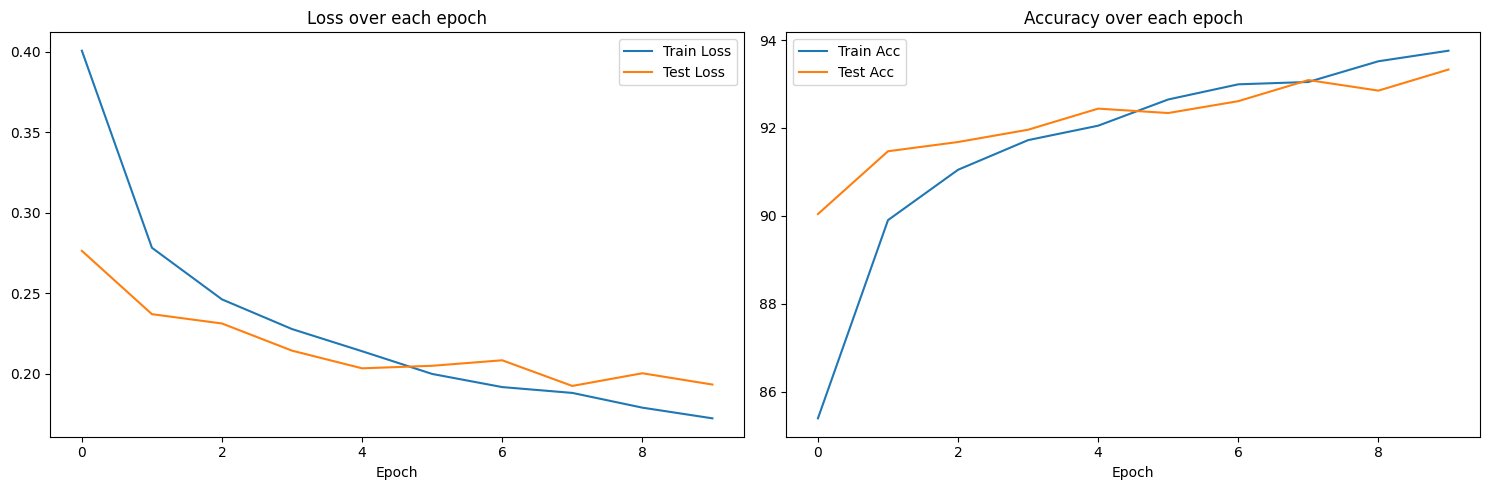

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['test_loss'],  label='Test Loss')
ax1.set_title('Loss over each epoch')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history['train_acc'], label='Train Acc')
ax2.plot(history['test_acc'],  label='Test Acc')
ax2.set_title('Accuracy over each epoch')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
all_preds = []
model.eval()

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)

print(f"Total predictions : {len(all_preds)}")
print(f"Sample predictions: {all_preds[:10]}")

Total predictions : 10000
Sample predictions: [np.int64(9), np.int64(2), np.int64(1), np.int64(1), np.int64(6), np.int64(1), np.int64(4), np.int64(6), np.int64(5), np.int64(7)]


In [ ]:
# We already have all the required images folder to test our model on. So we will directly move to testing it now.

In [ ]:
import pandas as pd

submission_ids   = []
submission_preds = []

model.eval()
with torch.no_grad():
    for images, image_ids in submission_loader:
        images  = images.to(device)
        outputs = model(images)
        preds   = outputs.argmax(dim=1).cpu().numpy()

        submission_ids.extend(image_ids)
        submission_preds.extend(preds)

submission_df = pd.DataFrame({
    'image_id': submission_ids,
    'label':    submission_preds
})

submission_df.to_csv('cnn_submission.csv', index=False)
print(submission_df)
print("\nSaved as cnn_submission.csv")

   image_id  label
0       000      5
1       001      1
2       002      7
3       003      4
4       004      3
..      ...    ...
95      095      6
96      096      9
97      097      7
98      098      9
99      099      7

[100 rows x 2 columns]

Saved as cnn_submission.csv
